In [13]:
import matplotlib.pyplot as plt
import pandas as pd

selected_results_fb15k = {
    "random": "../results/fb15k_10_0.001_random_test_positive_1738248353/all_metrics.txt",
    "greedy-p": "../results/fb15k_10_0.001_greedy_test_positive_1738249844/all_metrics.txt",
    "cosine-p": "../results/fb15k_10_0.001_cosine_0.1_test_positive/all_metrics.txt",
    "neural-p": "../results/fb15k_10_0.001_ltr_0.001_positive_1738509338/all_metrics_test_positive.txt",
    "neural-p-tanh": "/home/daniel/projects/quack/results/fb15k_10_0.001_ltr_1e-05_positive_1738688598/all_metrics_test_positive.txt",
    "greedy-n": "../results/fb15k_10_0.001_greedy_test_negative_1738251902/all_metrics.txt",
    "cosine-n": "../results/fb15k_10_0.001_cosine_0.9_test_negative_1738310587/all_metrics_test.txt",
    "neural-n": "../results/fb15k_10_0.001_ltr_0.001_positive_1738509338/all_metrics_test_negative.txt",
    "neural-n-tanh": "/home/daniel/projects/quack/results/fb15k_10_0.001_ltr_1e-05_positive_1738688598/all_metrics_test_negative.txt"
}

def process_files(file_dict, metric_name):
    data = []

    for method, file in file_dict.items():
        metrics = {}
        metrics["method"] = method
        all_values = []
        with open(file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 4:
                    continue  # Ignore malformed lines
                _, query_type, metric, value = parts
                value = float(value)
                if metric == f"{metric_name}:":
                    all_values.append(value)
                    metrics[f"{query_type}"] = f"{value * 100:.2f}"

        metrics["avg"] = f"{pd.Series(all_values).mean() * 100:.2f}"
        data.append(metrics)

    # Convert list of dicts to a DataFrame
    df = pd.DataFrame(data)
    return df

In [17]:
df_pa = process_files(selected_results_fb15k, "cumulative_pairwise_accuracy")
print("Cumulative Pairwise Accuracy")
# print(df_pa.to_latex(index=False))
df_pa

Cumulative Pairwise Accuracy


,method,1p,2p,3p,2i,3i,ip,pi,2in,3in,inp,pin,pni,2u-DNF,up-DNF,avg
0,random,12.12,21.57,20.78,12.90,9.83,21.48,16.78,21.21,17.62,19.50,22.15,25.16,22.29,22.08,18.96
1,greedy-p,70.88,61.03,60.47,64.75,65.68,59.22,60.55,63.17,62.59,61.64,61.95,63.33,62.86,60.85,62.78
2,cosine-p,83.15,80.04,80.64,80.07,79.79,78.15,77.52,77.61,77.35,81.93,80.40,78.07,78.68,80.44,79.56
3,neural-p,56.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.13
4,neural-p-tanh,78.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.47
5,greedy-n,76.53,74.36,73.70,75.29,73.66,74.35,74.58,76.89,76.41,73.57,74.98,76.56,76.36,74.53,75.13
6,cosine-n,68.10,67.39,67.82,62.84,60.46,68.97,64.32,69.76,64.94,66.45,67.90,69.20,68.11,66.87,66.65
7,neural-n,56.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.01
8,neural-n-tanh,76.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.65


In [16]:
df_mrr = process_files(selected_results_fb15k, "cumulative_mrr_hard_delta")
print("Relative MRR Delta")
# print(df_mrr.to_latex(index=False))
df_mrr

Relative MRR Delta


,method,1p,2p,3p,2i,3i,ip,pi,2in,3in,inp,pin,pni,2u-DNF,up-DNF,avg
0,random,-99.64,-98.74,-98.80,-99.85,-99.85,-98.12,-98.93,-99.17,-99.08,-97.54,-98.01,-93.41,-99.61,-99.35,-98.58
1,greedy-p,171.32,928.09,1028.32,47.72,45.29,1816.96,1060.87,745.85,727.15,1550.25,1353.55,4098.87,153.40,339.99,1004.83
2,cosine-p,-14.69,545.14,385.12,-53.83,-50.15,1180.28,414.85,199.76,222.99,634.29,530.75,1679.87,-20.36,60.10,408.15
3,neural-p,-11.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11.89
4,neural-p-tanh,-64.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-64.10
5,greedy-n,-54.45,-40.25,-38.82,-45.43,-49.53,-39.28,-39.43,-40.37,-41.53,-41.26,-39.66,-40.45,-39.65,-38.20,-42.02
6,cosine-n,-17.44,-22.29,-22.76,-18.05,-25.44,-28.48,-24.63,-21.85,-25.13,-24.39,-23.04,-21.77,-16.33,-19.01,-22.19
7,neural-n,-12.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12.02
8,neural-n-tanh,-80.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-80.74


In [10]:
selected_results_fb15k237 = {
    "random": "../results/fb15k237_10_0.0002_random_test_positive_1738320306/all_metrics_test_positive.txt",
    "cosine-p": "../results/fb15k237_10_0.0002_cosine_0.1_test_positive_1738455153/all_metrics_test_positive.txt",
    "cosine-n": "../results/fb15k237_10_0.0002_cosine_0.9_test_negative_1738459772/all_metrics_test_negative.txt",
}

In [11]:
df_pa = process_files(selected_results_fb15k237, "cumulative_pairwise_accuracy")
print("Cumulative Pairwise Accuracy")
print(df_pa.to_latex(index=False))

Cumulative Pairwise Accuracy
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & 33.02 & 44.26 & 49.08 & 33.54 & 29.89 & 42.49 & 38.03 & 40.99 & 37.60 & 46.72 & 45.36 & 43.28 & 40.98 & 46.13 & 40.81 \\
cosine-p & 84.83 & 82.92 & 83.19 & 80.61 & 77.08 & 81.45 & 80.30 & 80.22 & 79.58 & 83.24 & 82.00 & 80.76 & 81.38 & 82.19 & 81.41 \\
cosine-n & 72.19 & 72.04 & 71.72 & 63.80 & 59.74 & 72.56 & 66.97 & 73.11 & 66.04 & 70.66 & 71.50 & 72.75 & 72.92 & 70.32 & 69.74 \\
\bottomrule
\end{tabular}



In [12]:
df_mrr = process_files(selected_results_fb15k237, "cumulative_mrr_hard_delta")
print("Relative MRR Delta")
print(df_mrr.to_latex(index=False))

Relative MRR Delta
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & -98.14 & -95.37 & -95.46 & -99.39 & -99.60 & -96.96 & -98.62 & -97.28 & -98.57 & -94.63 & -95.10 & -85.71 & -97.51 & -96.15 & -96.32 \\
cosine-p & 377.94 & 1214.44 & 777.76 & 41.82 & 6.57 & 749.08 & 249.20 & 505.69 & 480.51 & 996.82 & 1174.60 & 2759.52 & 361.01 & 684.97 & 741.42 \\
cosine-n & -20.59 & -28.96 & -28.02 & -13.60 & -17.21 & -29.40 & -23.67 & -21.81 & -17.75 & -31.34 & -28.67 & -24.06 & -15.63 & -23.02 & -23.12 \\
\bottomrule
\end{tabular}



In [32]:
def plot_pa_mrr(df_pa, df_mrr):
    df_pa["1p"] = df_pa["1p"].astype(float)
    df_mrr["1p"] = df_mrr["1p"].astype(float)

    fig, ax = plt.subplots()
    ax.scatter(df_pa["1p"], df_mrr["1p"])
    for i, txt in enumerate(df_pa["method"]):
        ax.annotate(txt, (df_pa["1p"][i], df_mrr["1p"][i]))
    plt.xlabel("Pairwise Accuracy")
    plt.ylabel("$\Delta$MRR")
    plt.xlim(0, 100)
    plt.ylim(-150, 200)
    plt.grid()

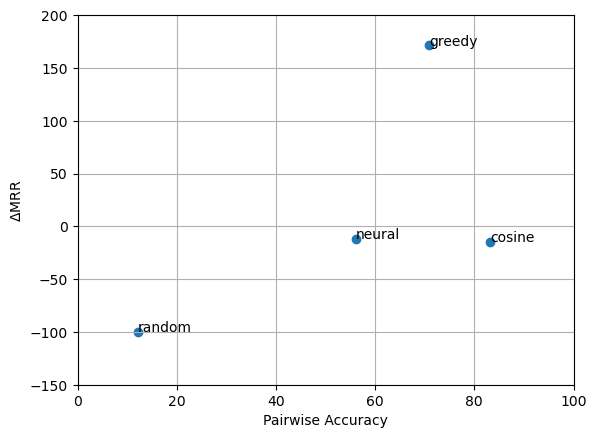

In [34]:
selected_results_fb15k = {
    "random": "../results/fb15k_10_0.001_random_test_positive_1738248353/all_metrics.txt",
    "greedy": "../results/fb15k_10_0.001_greedy_test_positive_1738249844/all_metrics.txt",
    "cosine": "../results/fb15k_10_0.001_cosine_0.1_test_positive/all_metrics.txt",
    "neural": "../results/fb15k_10_0.001_ltr_0.001_positive_1738509338/all_metrics_test_positive.txt"
}
df_pa = process_files(selected_results_fb15k, "cumulative_pairwise_accuracy")
df_mrr = process_files(selected_results_fb15k, "cumulative_mrr_hard_delta")
plot_pa_mrr(df_pa, df_mrr)

In [ ]:
selected_results_fb15k = {
    "random": "../results/fb15k_10_0.001_random_test_positive_1738248353/all_metrics.txt",
    "greedy": "../results/fb15k_10_0.001_greedy_test_positive_1738249844/all_metrics.txt",
    "cosine": "../results/fb15k_10_0.001_cosine_0.1_test_positive/all_metrics.txt",
    "neural": "../results/fb15k_10_0.001_ltr_0.001_positive_1738509338/all_metrics_test_positive.txt"
}
df_pa = process_files(selected_results_fb15k, "cumulative_pairwise_accuracy")
df_mrr = process_files(selected_results_fb15k, "cumulative_mrr_hard_delta")
plot_pa_mrr(df_pa, df_mrr)

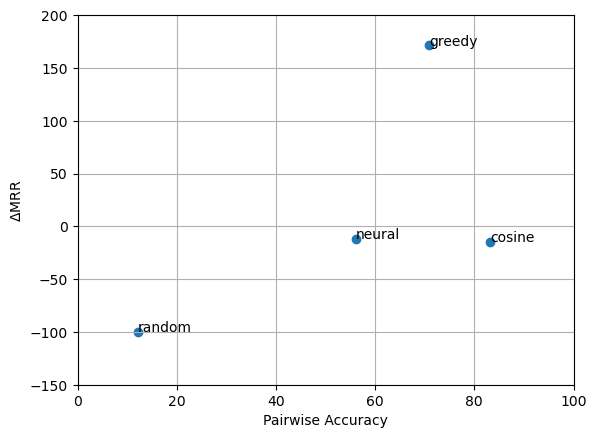

In [30]:
# Scatter plot of pairwise accuracy and MRR


